# Experimenting with the results of the FlexNet model and AIXI-Shape experimentation for explainability



In [1]:
import os
import glob
import json
import random
import datetime
import re
import cv2
import math
from typing import List, Optional, Dict, Any, Tuple

import numpy as np
from pathlib import Path

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, IterableDataset, TensorDataset
from torchvision import transforms

import matplotlib.pyplot as plt
from PIL import Image

from scipy.stats import ttest_ind

from captum.concept import TCAV, Concept, Classifier
from captum.attr import LayerGradientXActivation, LayerIntegratedGradients
from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str


from model.model_sq import TNet
from tools import plotting, metrics, model_io, tcav, data, utils
from tools.plotting import plot_concepts
from model.model_dylan import FlexibleTNet  



/opt/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


User defined global vars

In [2]:
PESOS = "saved_models/circle_minimal_2f_64fc.pt"
DEVICE = torch.device('cpu')

Data manipulation, loading and visualization helper-functions

In [4]:
def transform(img):
    return transforms.Compose(
        [
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ]
    )(img)

def get_tensor_from_filename(filename):
    img = Image.open(filename).convert("RGB")
    return transform(img)

def load_image_tensors(class_name, root_path='data/tcav/image/imagenet/', transform=True):
    path = os.path.join(root_path, class_name)
    filenames = glob.glob(path + '/*.jpg')

    tensors = []
    for filename in filenames:
        img = Image.open(filename).convert('RGB')
        tensors.append(transform(img) if transform else img)
    
    return tensors

def assemble_concept(name, id, concepts_path="data/tcav/image/concepts/"):
    concept_path = os.path.join(concepts_path, name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)

    return Concept(id=id, name=name, data_iter=concept_iter)


Create the concepts

In [5]:
concepts_path = "concepts_subset"

circle_full        = assemble_concept("circle_full", 0, concepts_path=concepts_path)
cross_full         = assemble_concept("cross_full", 1, concepts_path=concepts_path)
square_full        = assemble_concept("square_full", 2, concepts_path=concepts_path)
random_pool        = assemble_concept("random_pool_3", 3, concepts_path=concepts_path)
random_pool_2        = assemble_concept("random_pool_4", 4, concepts_path=concepts_path)


Visualize the concepts

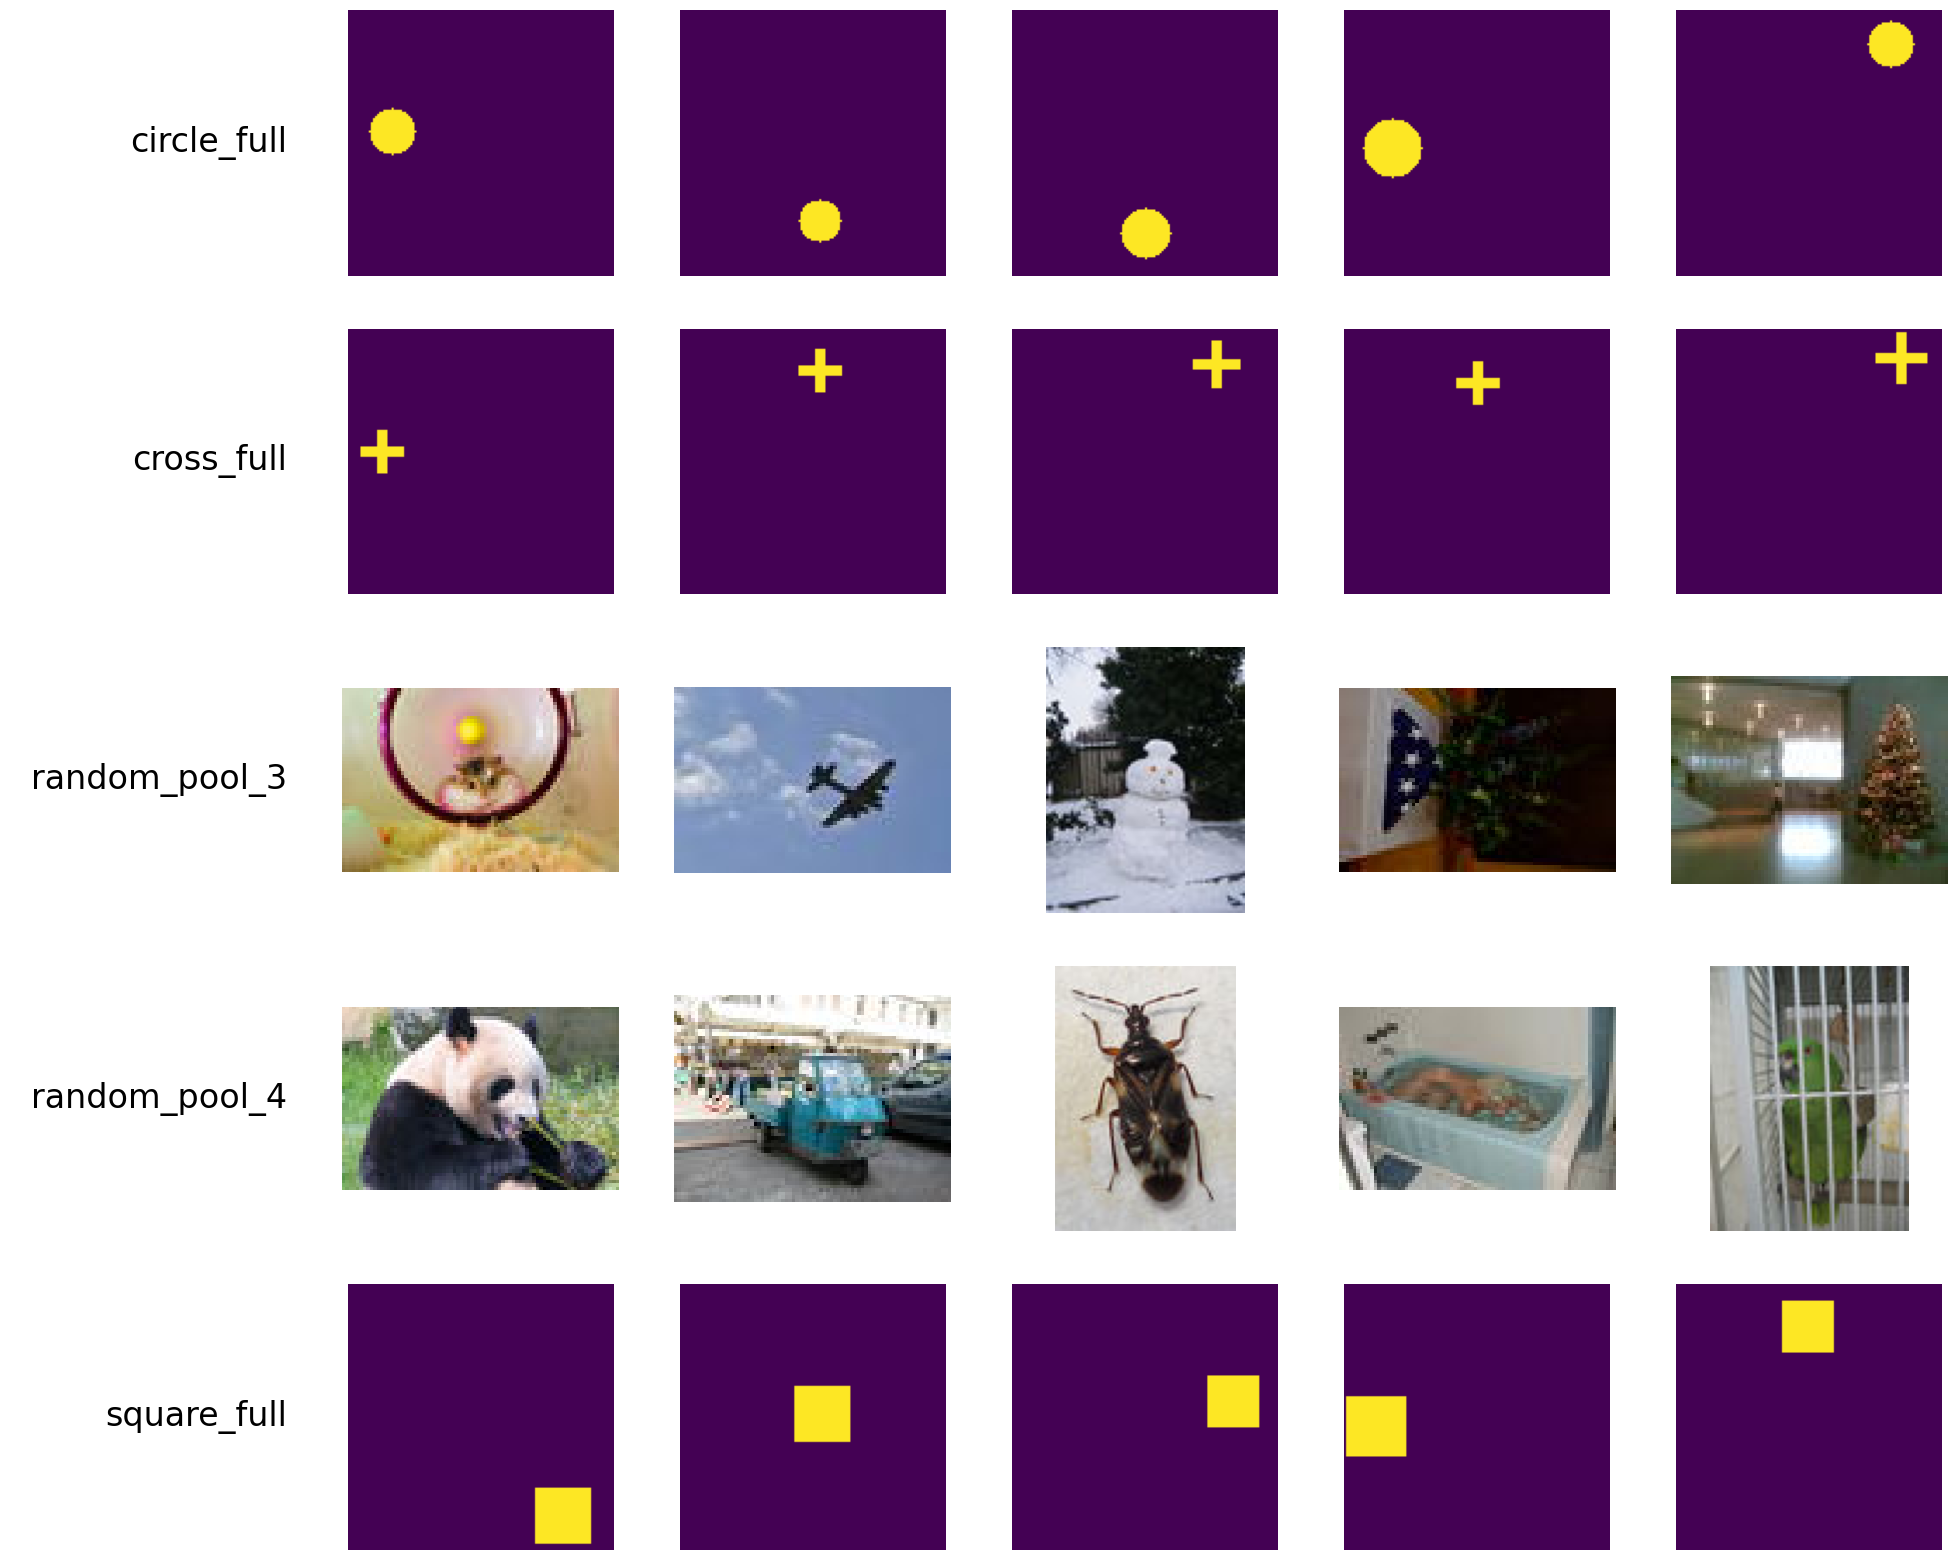

In [6]:
plot_concepts(5, 5, [circle_full, cross_full, random_pool, random_pool_2, square_full], concepts_path)

We proceed to load the model and it's weights. This is for Conv1 and FC1 FlexNet model.

In [7]:
def load_simple_model(weights_path: str, device=None):   
    conv_channels = [2]
    fc_layers = [64]

    model = FlexibleTNet(
        num_channels=3,
        num_classes=1,
        conv_channels=conv_channels,
        fc_layers=fc_layers,
        do_sigmoid=False,
        size_img=128
    )

    state = torch.load(weights_path, map_location=device)
    model.load_state_dict(state)
    model.to(device).eval()
    return model

model = load_simple_model(PESOS, DEVICE)
model


FlexibleTNet(
  (conv_layers): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 2, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (1): ReLU()
      (2): BatchNorm2d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (fc_layers): Sequential(
    (0): Sequential(
      (0): Linear(in_features=8192, out_features=64, bias=True)
      (1): Dropout(p=0.2, inplace=False)
      (2): ReLU()
    )
  )
  (output): Linear(in_features=64, out_features=1, bias=True)
  (final_act): Identity()
)

Minimal visualization of the networks predictions vs gt

In [12]:
with open("data/gt_train_discrete.json", "r") as f:
    labels_train = json.load(f)

print("First 10 labels:", labels_train[:10])

First 10 labels: [1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0]


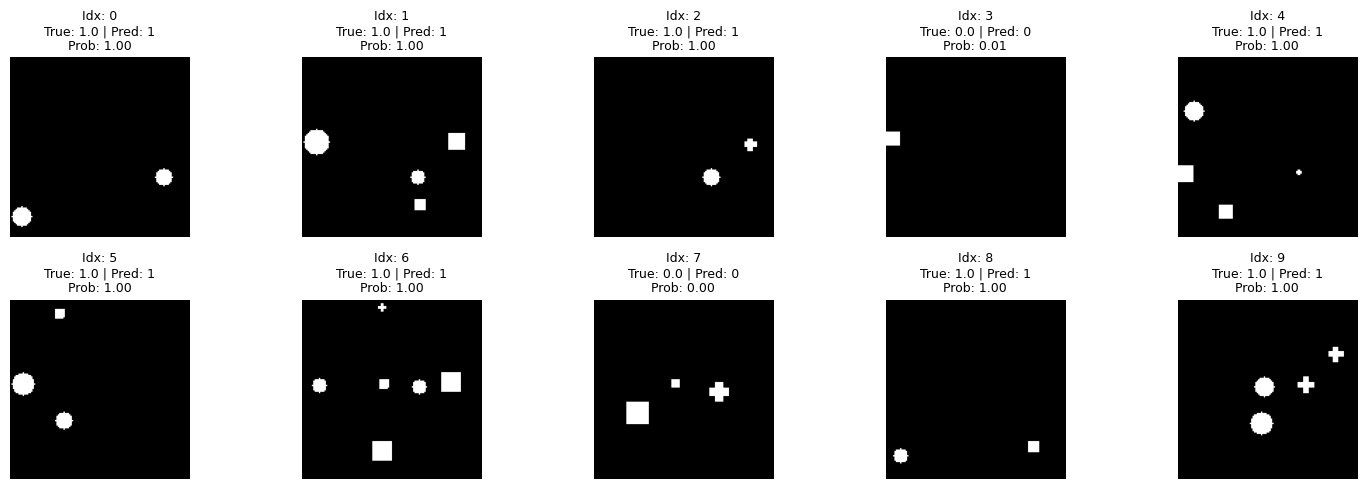

In [13]:
def predict_prob(model, img_path):
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = torch.sigmoid(model(x)).item()
    return p


num_to_show = 10
plt.figure(figsize=(15, 5))

for i in range(num_to_show):
    path = os.path.join("data/aixi_shape", "train", f"{i:05d}.png")
    label_true = labels_train[i]

    
    prob = predict_prob(model, path)
    label_pred = 1 if prob > 0.5 else 0

    
    img = Image.open(path).convert("RGB")

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(
        f"Idx: {i}\nTrue: {label_true} | Pred: {label_pred}\nProb: {prob:.2f}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [56]:
def visualize_activations(model, img_path, transform, layer_idx=0, cols=5, cmap="viridis", save=False):
    """
    Visualize convolutional activation maps at maximum resolution.
    """
    model.eval()
    device = next(model.parameters()).device

    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    activations = {}
    def hook_fn(_, __, output):
        activations['feat'] = output.detach().cpu()

    conv_layers = [m for m in model.modules() if isinstance(m, torch.nn.Conv2d)]
    if layer_idx >= len(conv_layers):
        raise ValueError(f"Layer index {layer_idx} out of range. Model has {len(conv_layers)} conv layers.")

    handle = conv_layers[layer_idx].register_forward_hook(hook_fn)
    _ = model(x)
    handle.remove()

    feat = activations['feat'][0]
    num_maps = feat.shape[0]
    rows = math.ceil(num_maps / cols)

    # High DPI for maximum resolution
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5), dpi=300)
    fig.suptitle(f"Layer {layer_idx}: {num_maps} activation maps", fontsize=12)
    axes = np.array(axes).reshape(-1)

    for i in range(num_maps):
        fmap = feat[i].numpy()
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-5)
        axes[i].imshow(fmap, cmap=cmap, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(f"Map {i}", fontsize=8)

    for j in range(num_maps, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    if save:
        plt.savefig(f"activations_layer{layer_idx}.png", dpi=600, bbox_inches="tight", pad_inches=0.1)
    plt.show()

    plt.figure(figsize=(3, 3), dpi=300)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

Beautiful Activations maps of the network

Model has 1 convolutional layers


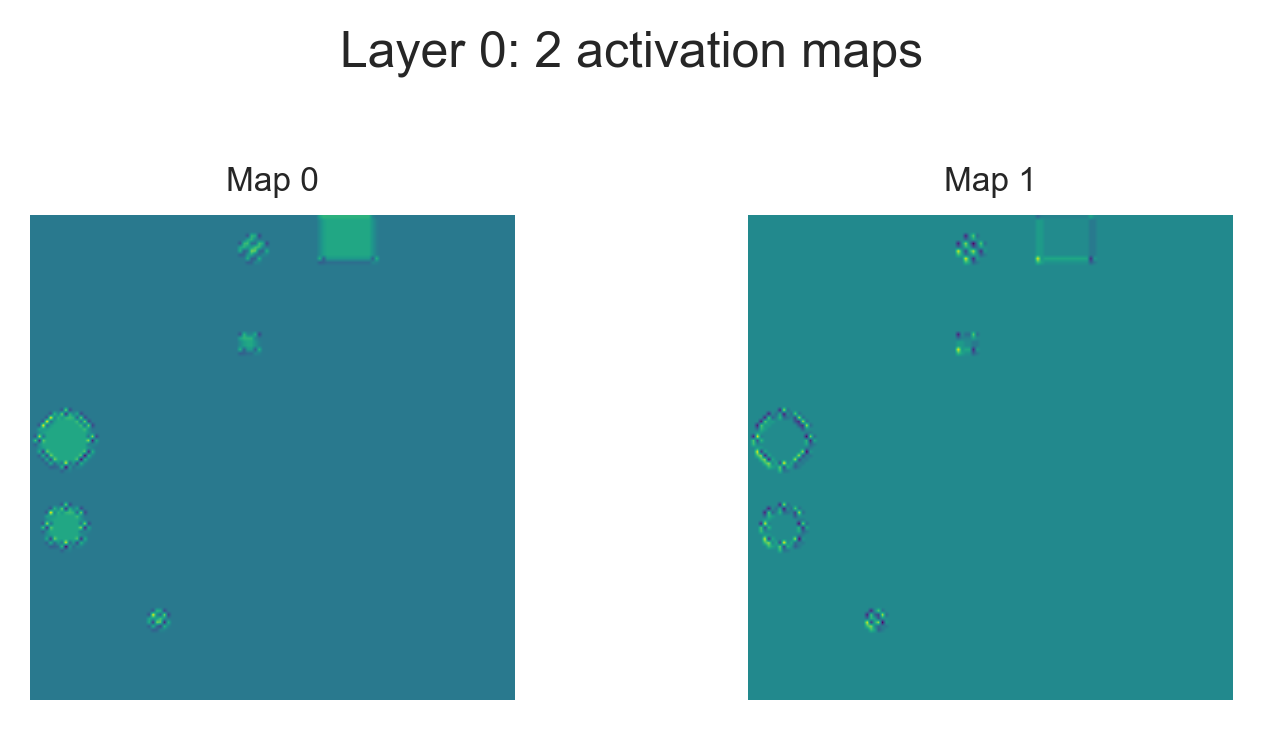

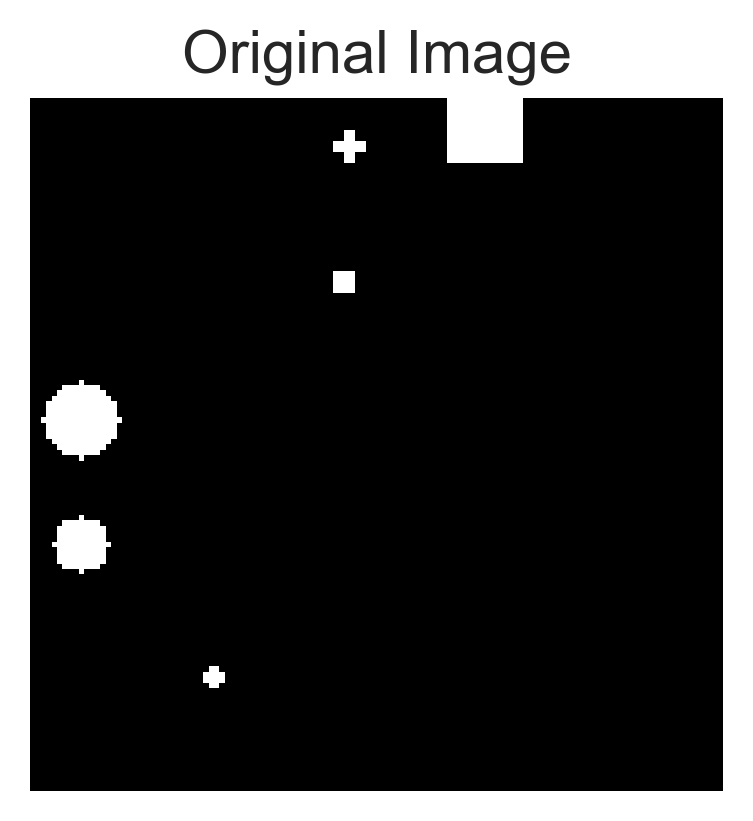

In [ ]:
conv_layers = [m for m in model.modules() if isinstance(m, torch.nn.Conv2d)]
print(f"Model has {len(conv_layers)} convolutional layers")

visualize_activations(model, "data/aixi_shape/val/00050.png", transform, layer_idx=0, cols=2, cmap="viridis")

## Experimentation with mixed image

torch.Size([1, 3, 128, 128])


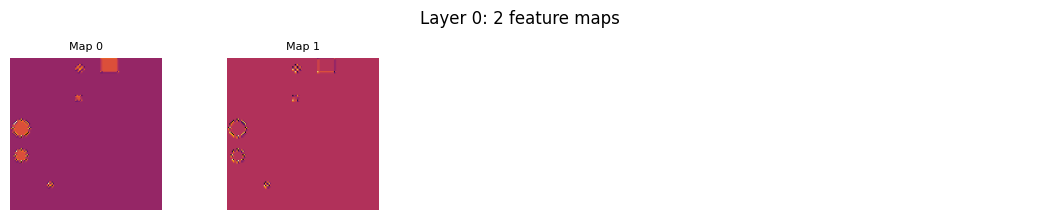

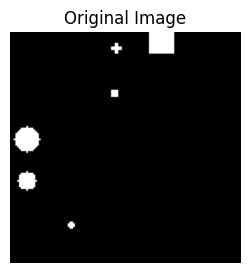

In [47]:
x_mix1 = transform(Image.open("data/aixi_shape/val/00050.png").convert('RGB')).unsqueeze(0).to(DEVICE)
visualize_activations(model, "data/aixi_shape/val/00050.png", layer_idx=0, cols=5)

In [11]:
model.eval()
model(x_mix1)

tensor([[41.2392]], grad_fn=<AddmmBackward0>)

In [12]:
LAYERS = [
    "conv_layers.0.0",   
    "fc_layers.0.0"
]


In [13]:
experimental_set_rand = [[circle_full, random_pool], [circle_full, random_pool_2]]

In [14]:
def format_float(f):
    return float('{:.3f}'.format(f) if abs(f) >= 0.0005 else '{:.3e}'.format(f))

def plot_tcav_scores(experimental_sets, tcav_scores):
    fig, ax = plt.subplots(1, len(experimental_sets), figsize = (25, 7))

    barWidth = 1 / (len(experimental_sets[0]) + 1)

    for idx_es, concepts in enumerate(experimental_sets):

        concepts = experimental_sets[idx_es]
        concepts_key = concepts_to_str(concepts)

        pos = [np.arange(len(LAYERS))]
        for i in range(1, len(concepts)):
            pos.append([(x + barWidth) for x in pos[i-1]])
        _ax = (ax[idx_es] if len(experimental_sets) > 1 else ax)
        for i in range(len(concepts)):
            val = [format_float(scores['sign_count'][i]) for layer, scores in tcav_scores[concepts_key].items()]
            _ax.bar(pos[i], val, width=barWidth, edgecolor='white', label=concepts[i].name)

        
        _ax.set_xlabel('Set {}'.format(str(idx_es)), fontweight='bold', fontsize=16)
        _ax.set_xticks([r + 0.3 * barWidth for r in range(len(LAYERS))])
        _ax.set_xticklabels(LAYERS, fontsize=16)

        
        _ax.legend(fontsize=16)

    plt.show()

def plot_conceptual_sensitivity(experimental_sets, tcav_scores, layers):
    
    fig, ax = plt.subplots(1, len(experimental_sets), figsize=(25, 7))
    if len(experimental_sets) == 1:
        ax = [ax]

    barWidth = 1 / (len(experimental_sets[0]) + 1)

    for idx_es, concepts in enumerate(experimental_sets):
        concepts_key = list(tcav_scores.keys())[idx_es]
        _ax = ax[idx_es]

        pos = [np.arange(len(layers))]
        for i in range(1, len(concepts)):
            pos.append([x + barWidth for x in pos[i - 1]])

        for i, concept in enumerate(concepts):
            val = []
            for layer in layers:
                try:
                    val.append(float(tcav_scores[concepts_key][layer]['magnitude'][i]))
                except (KeyError, IndexError):
                    val.append(0.0)

            colors = ['#2ca02c' if v >= 0 else '#d62728' for v in val]
            bars = _ax.bar(pos[i], val, width=barWidth, color=colors,
                           edgecolor='black', label=concept.name)
            for rect, v in zip(bars, val):
                height = rect.get_height()
                _ax.text(
                    rect.get_x() + rect.get_width() / 2,
                    height + (0.03 if v >= 0 else -0.05),
                    format_float(v),
                    ha='center',
                    va='bottom' if v >= 0 else 'top',
                    fontsize=10,
                    rotation=0,
                    color='black'
                )

        _ax.set_xlabel(f'Set {idx_es}', fontweight='bold', fontsize=14)
        _ax.set_xticks([r + (len(concepts) * barWidth) / 2 - barWidth / 2 for r in range(len(layers))])
        _ax.set_xticklabels(layers, fontsize=12)
        _ax.set_ylabel('Conceptual Sensitivity (Magnitude)', fontsize=14)
        _ax.axhline(0, color='black', linewidth=1)
        _ax.legend(fontsize=12)
        _ax.grid(axis='y', linestyle='--', alpha=0.5)

        _ax.set_title(" | ".join([c.name for c in concepts]), fontsize=14, pad=15)

    plt.tight_layout()
    plt.show()

In [15]:
mytcav = TCAV(model=model,
              layers=LAYERS,
              layer_attr_method = LayerIntegratedGradients(
                model, None, multiply_by_inputs=False))

rand_circle_results = mytcav.interpret(inputs=x_mix1,
                                                experimental_sets=experimental_set_rand,
                                                target=0,
                                                n_steps=5,
                                               )
rand_circle_results

/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()
/opt/miniconda3/lib/python3.12/site-packages/captum/_utils/models/linear_model/train.py:409: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  bias_values = torch.FloatTensor([sklearn_model.intercept_]).to(  # type: ignore


defaultdict(<function captum.concept._core.tcav.TCAV.interpret.<locals>.<lambda>()>,
            {'0-3': defaultdict(None,
                         {'conv_layers.0.0': {'sign_count': tensor([0., 1.]),
                           'magnitude': tensor([-183.2228,  183.2228])},
                          'fc_layers.0.0': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 11.7188, -11.7188])}}),
             '0-4': defaultdict(None,
                         {'conv_layers.0.0': {'sign_count': tensor([0., 1.]),
                           'magnitude': tensor([-220.2764,  220.2764])},
                          'fc_layers.0.0': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 1.3550, -1.3550])}})})

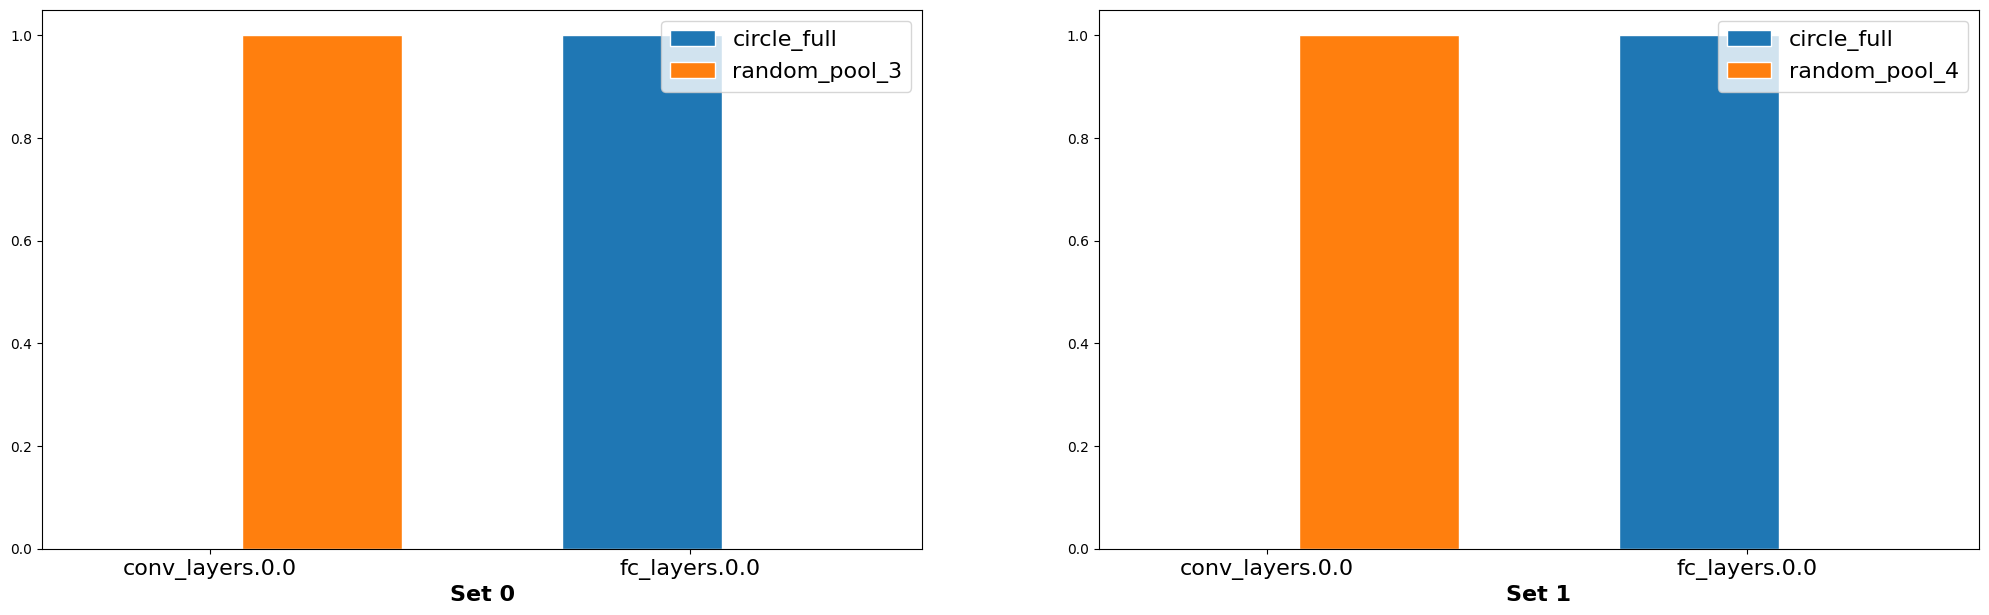

In [16]:
plot_tcav_scores(experimental_set_rand, rand_circle_results)

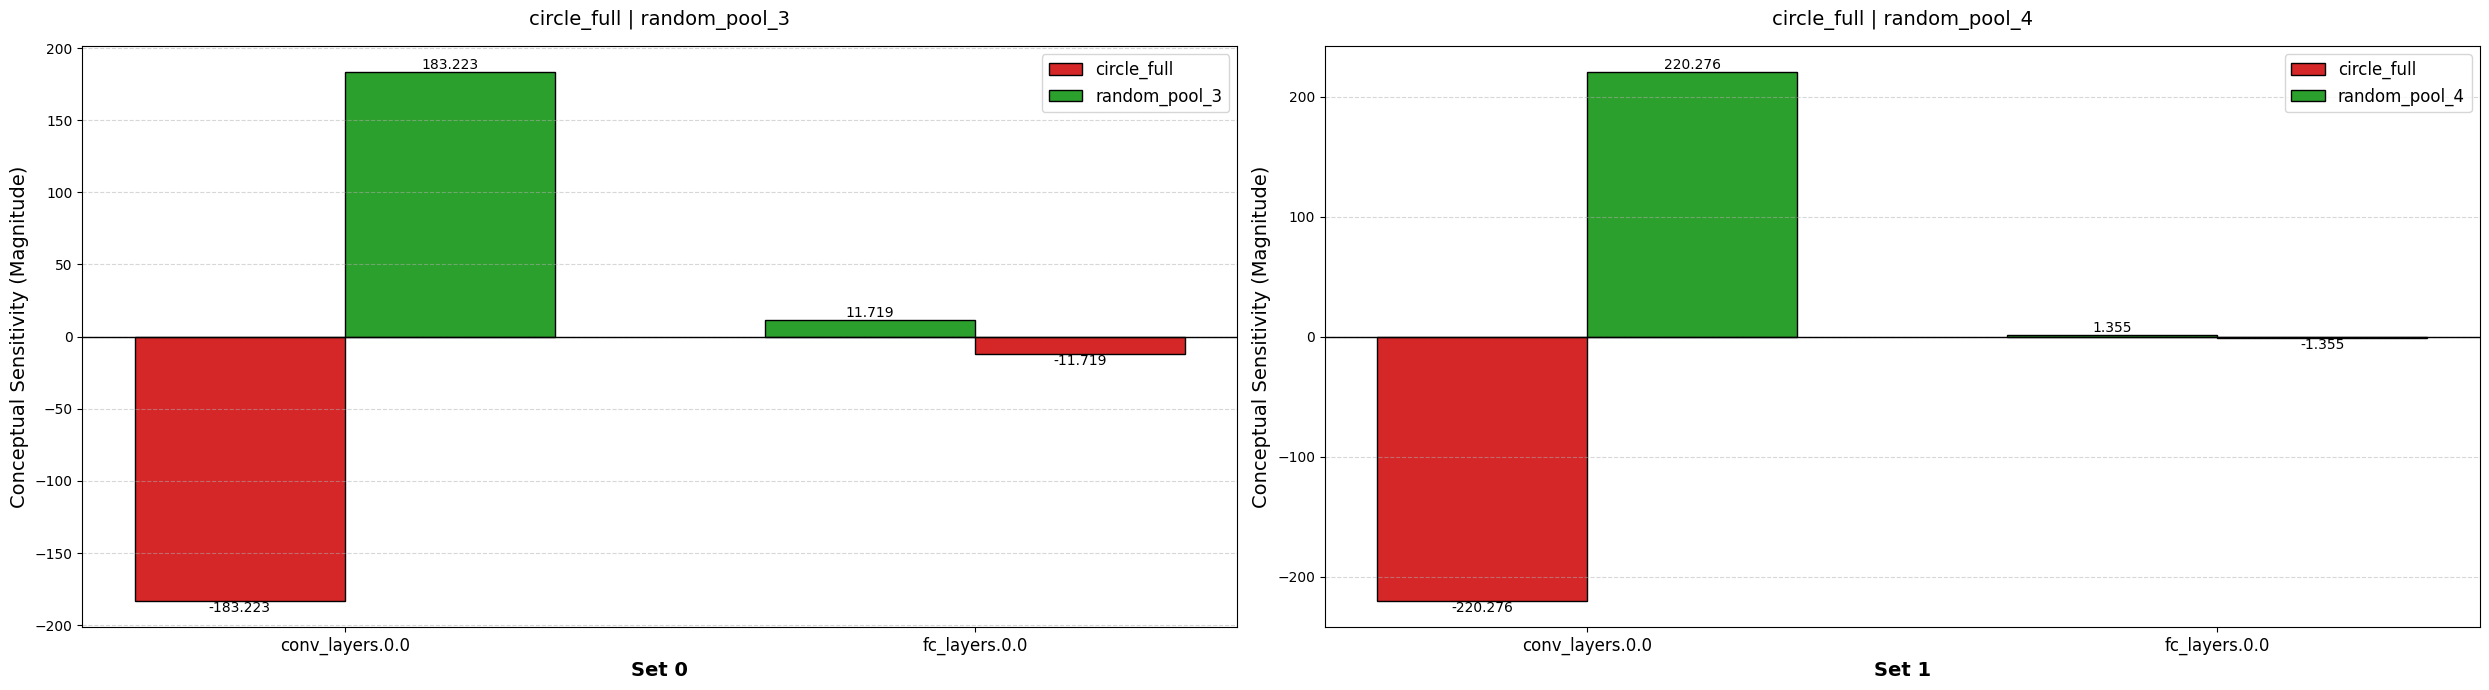

In [17]:
plot_conceptual_sensitivity(experimental_set_rand, rand_circle_results, LAYERS)

In [18]:
cross_concept_set = [[circle_full, cross_full, square_full]]
mytcav_cross_concepts = TCAV(model=model,
              layers=LAYERS,
              layer_attr_method = LayerIntegratedGradients(
                model, None, multiply_by_inputs=False))

cross_concept_results = mytcav.interpret(inputs=x_mix1,
                                                experimental_sets=cross_concept_set,
                                                target=0,
                                                n_steps=5,
                                               )
cross_concept_results

/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


defaultdict(<function captum.concept._core.tcav.TCAV.interpret.<locals>.<lambda>()>,
            {'0-1-2': defaultdict(None,
                         {'conv_layers.0.0': {'sign_count': tensor([0., 0., 1.]),
                           'magnitude': tensor([ -1.4434, -80.5582,  74.1679])},
                          'fc_layers.0.0': {'sign_count': tensor([1., 1., 0.]),
                           'magnitude': tensor([ 1.3547,  0.4354, -0.3193])}})})

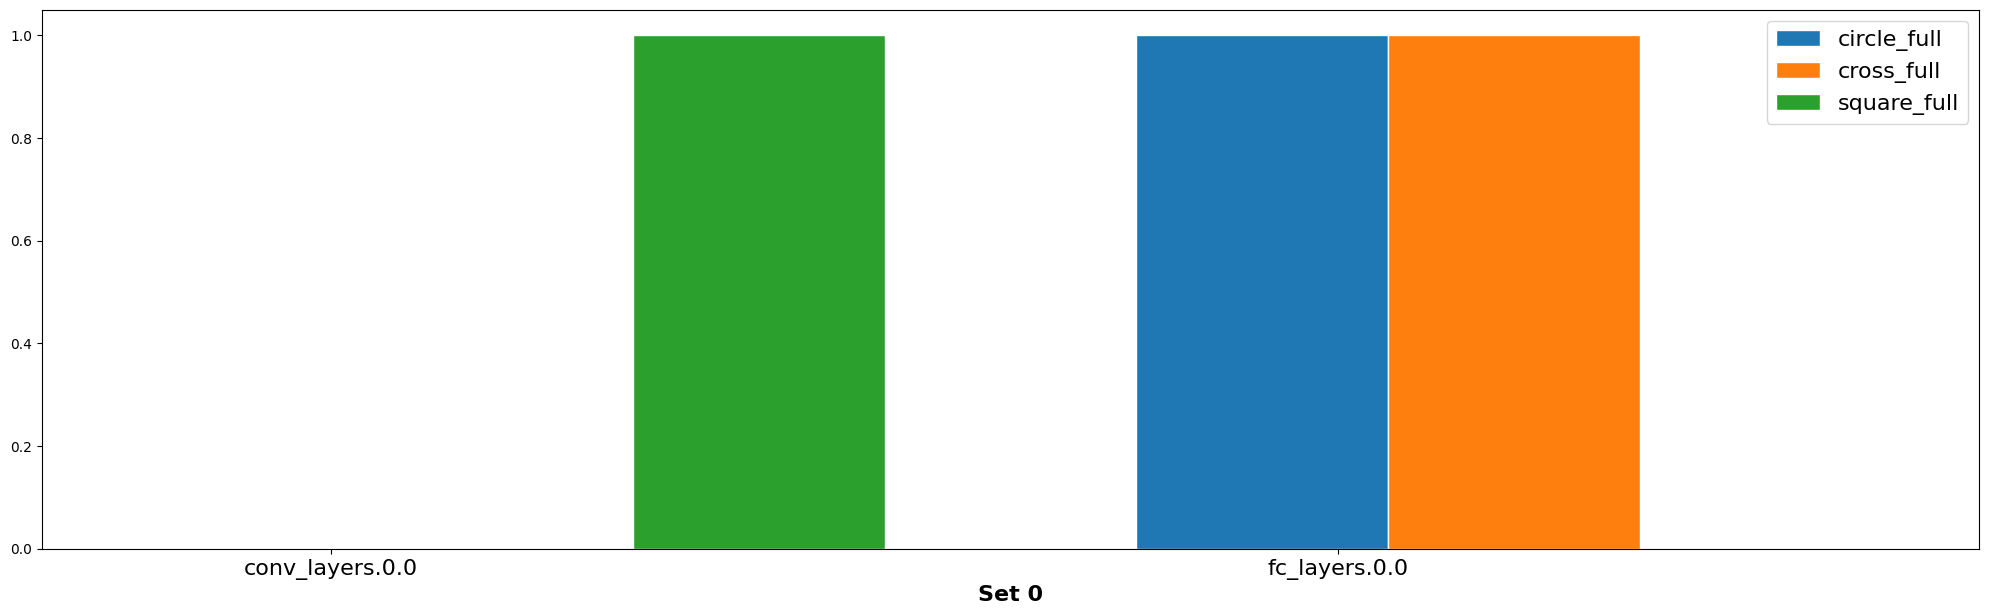

In [19]:
plot_tcav_scores(cross_concept_set, cross_concept_results)

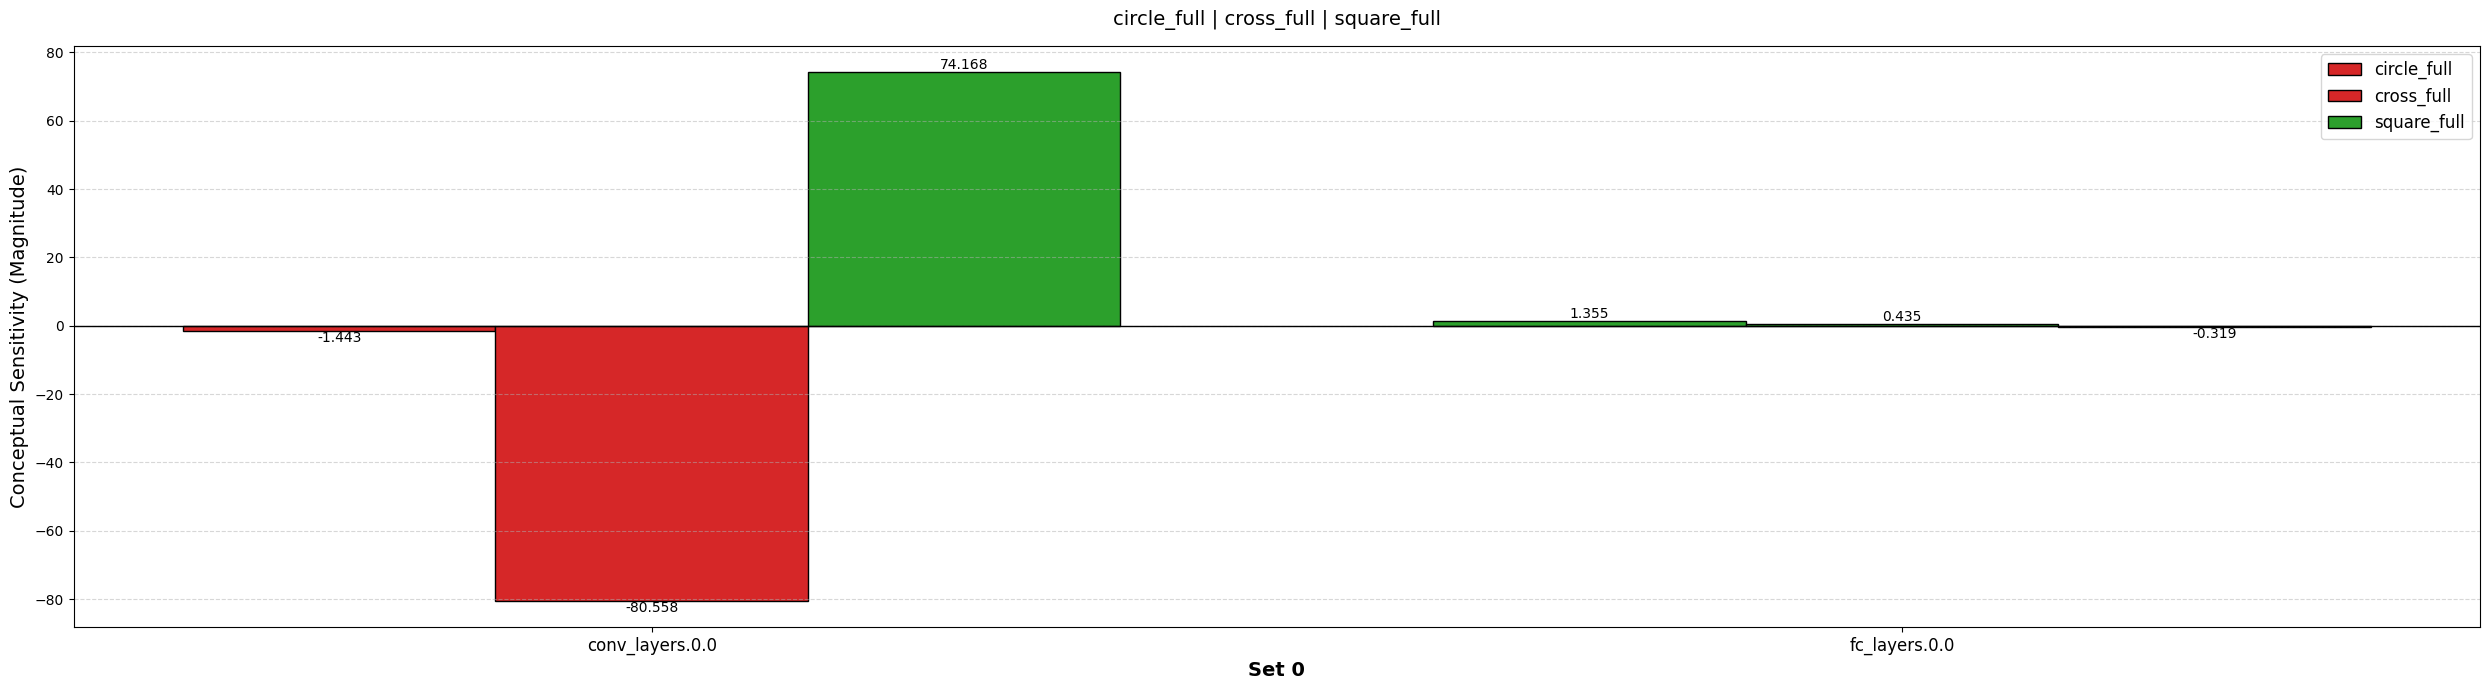

In [20]:
plot_conceptual_sensitivity(cross_concept_set, cross_concept_results, LAYERS)

## Single figure experimentations

### Double circle experimentation

torch.Size([1, 3, 128, 128])


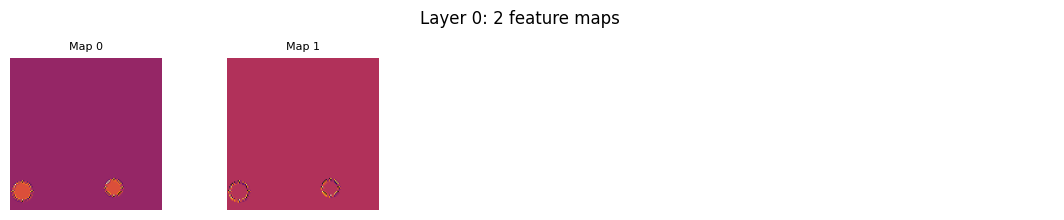

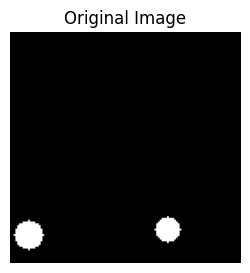

In [48]:
circle_test = Image.open("data/aixi_shape/val/00124.png").convert("RGB")
circle_test
visualize_activations(model, "data/aixi_shape/val/00124.png", layer_idx=0, cols=5)

In [22]:
x_circle = transform(Image.open("data/aixi_shape/val/00124.png").convert('RGB')).unsqueeze(0).to(DEVICE)
x_circle.shape

torch.Size([1, 3, 128, 128])

In [23]:
model(x_circle)

tensor([[43.3520]], grad_fn=<AddmmBackward0>)

In [24]:
mytcav = TCAV(model=model,
              layers=LAYERS,
              layer_attr_method = LayerIntegratedGradients(
                model, None, multiply_by_inputs=False))

double_circle_image = mytcav.interpret(inputs=x_mix1,
                                                experimental_sets=cross_concept_set,
                                                target=0,
                                                n_steps=5,
                                               )
double_circle_image

/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


defaultdict(<function captum.concept._core.tcav.TCAV.interpret.<locals>.<lambda>()>,
            {'0-1-2': defaultdict(None,
                         {'conv_layers.0.0': {'sign_count': tensor([1., 0., 1.]),
                           'magnitude': tensor([  4.0329, -69.8976,  52.5471])},
                          'fc_layers.0.0': {'sign_count': tensor([1., 1., 0.]),
                           'magnitude': tensor([ 2.4155,  0.2974, -0.4341])}})})

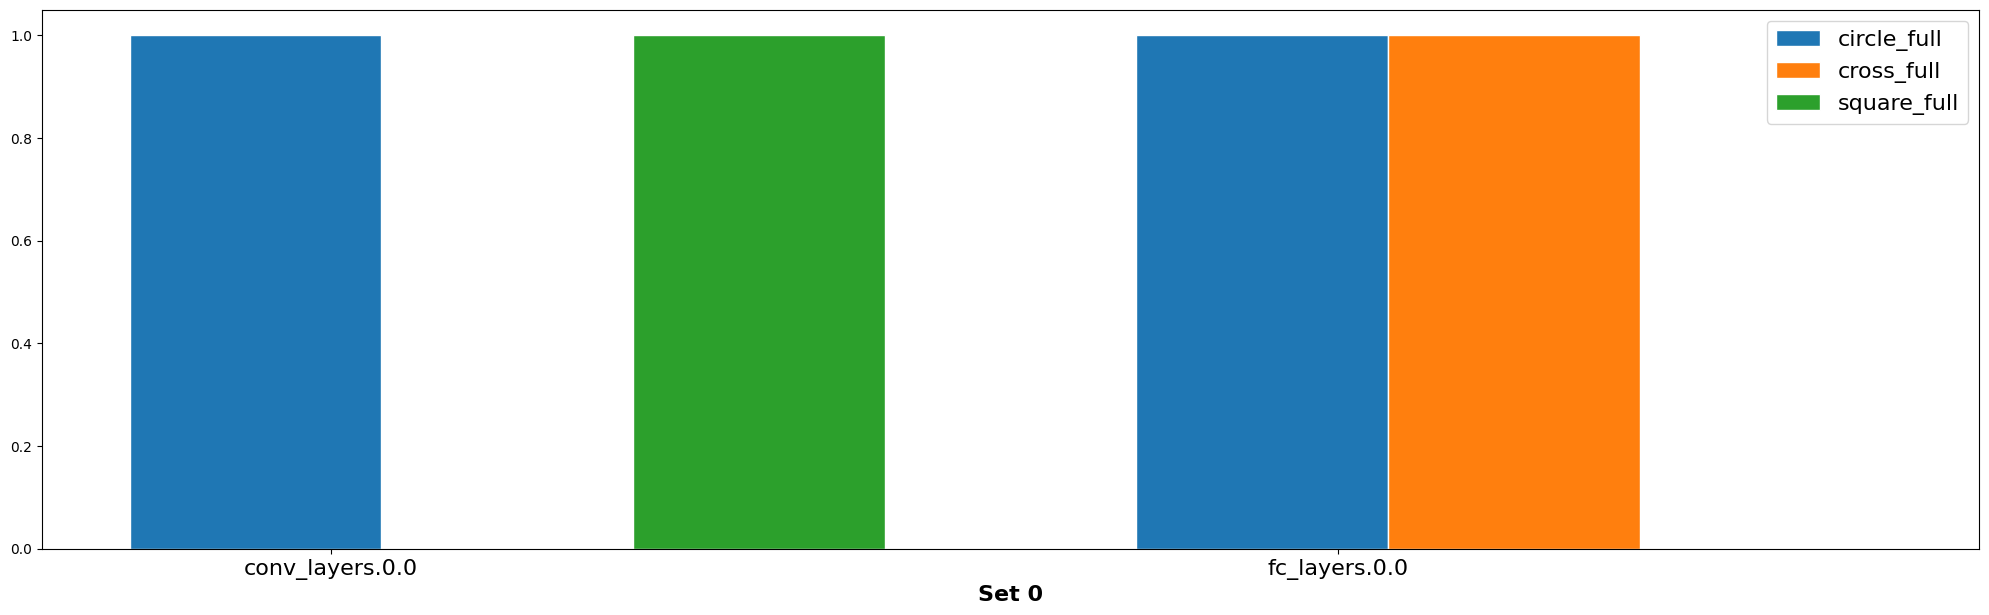

In [25]:
plot_tcav_scores(cross_concept_set, double_circle_image)

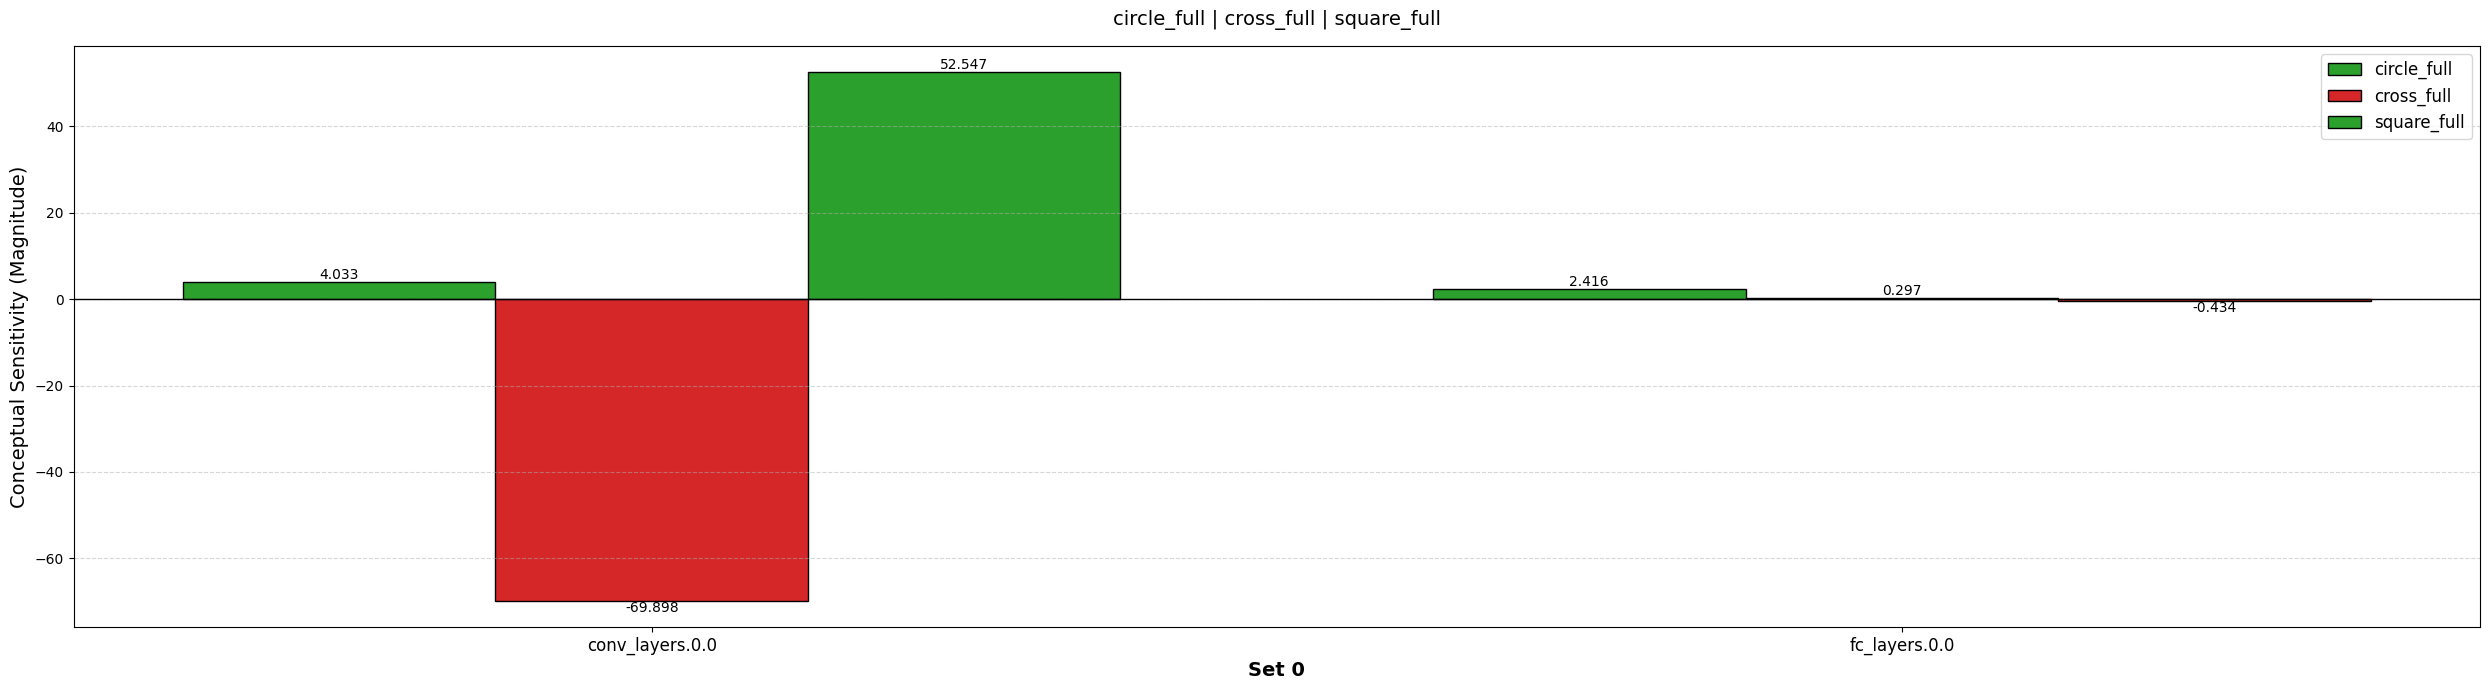

In [26]:
plot_conceptual_sensitivity(cross_concept_set, double_circle_image, LAYERS)

### Single Circle

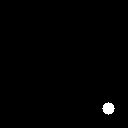

In [27]:
circle_test = Image.open("data/aixi_shape/val/00332.png").convert("L")
circle_test

In [28]:
x_cercle = transform(Image.open("data/aixi_shape/val/00332.png").convert("RGB")).unsqueeze(0).to(DEVICE)
x_cercle.shape

torch.Size([1, 3, 128, 128])

In [29]:
model(x_cercle)

tensor([[18.0749]], grad_fn=<AddmmBackward0>)

In [31]:
mytcav = TCAV(model=model,
              layers=LAYERS,
              layer_attr_method = LayerIntegratedGradients(
                model, None, multiply_by_inputs=False))
single_circle_results = mytcav.interpret(inputs=x_cercle,
                                        experimental_sets=cross_concept_set,
                                        target=0,
                                        n_steps=5,
                                       )
single_circle_results

defaultdict(<function captum.concept._core.tcav.TCAV.interpret.<locals>.<lambda>()>,
            {'0-1-2': defaultdict(None,
                         {'conv_layers.0.0': {'sign_count': tensor([1., 0., 1.]),
                           'magnitude': tensor([ 10.5668, -94.7509,  66.6059])},
                          'fc_layers.0.0': {'sign_count': tensor([1., 0., 0.]),
                           'magnitude': tensor([ 1.3492, -1.4302, -0.6282])}})})

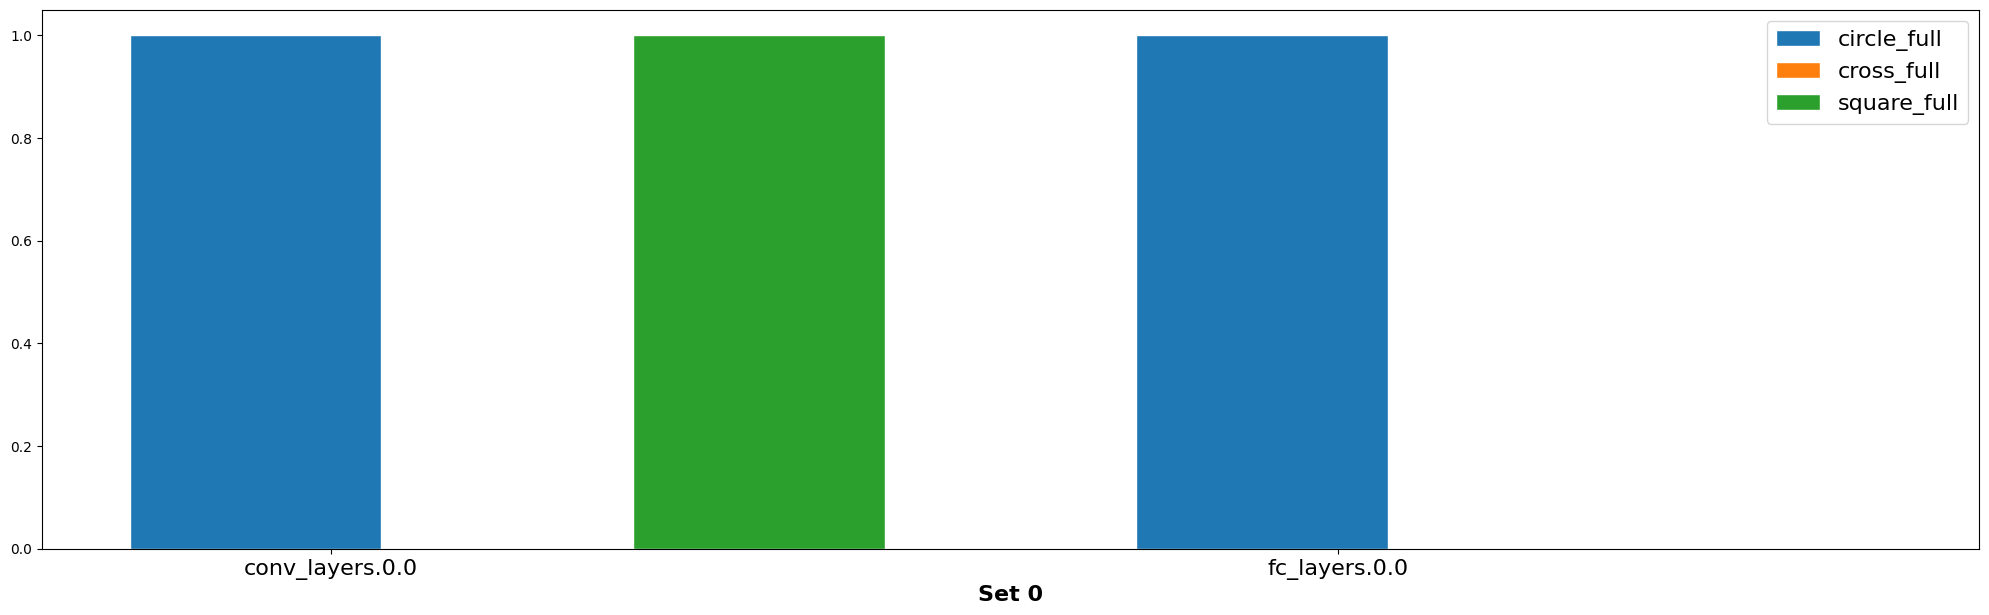

In [32]:
plot_tcav_scores(cross_concept_set, single_circle_results)

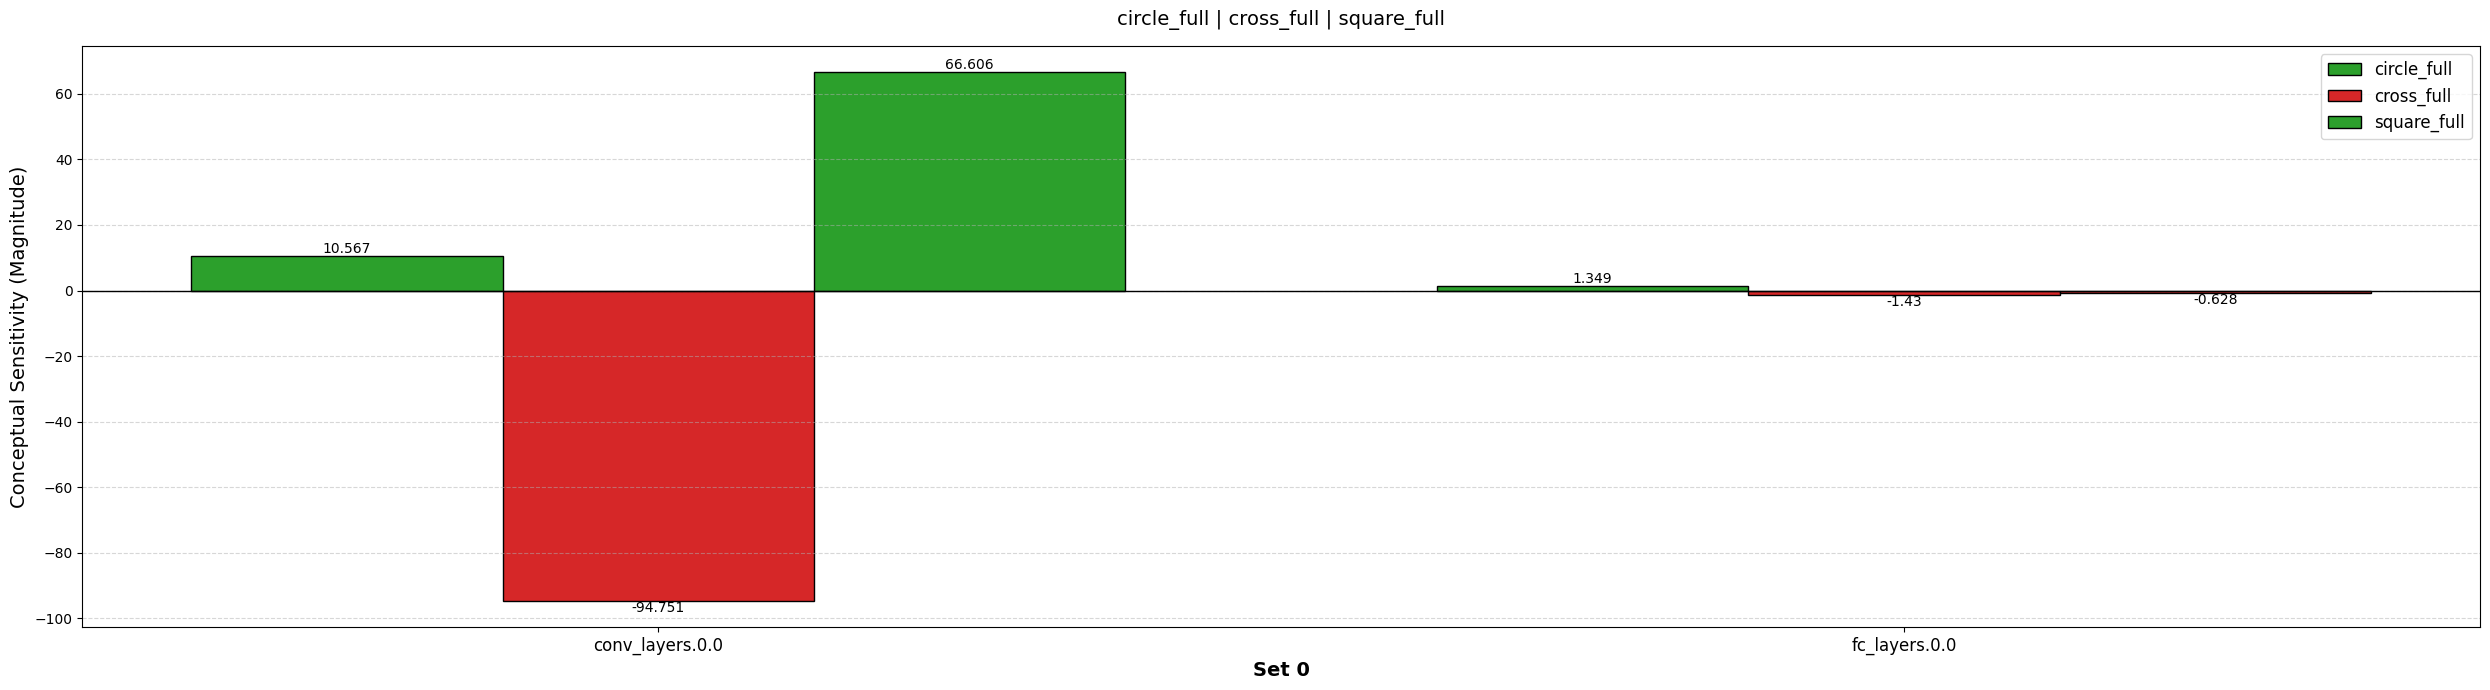

In [33]:
plot_conceptual_sensitivity(cross_concept_set, single_circle_results, LAYERS)

### No circle-multiple image

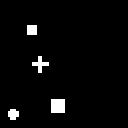

In [34]:
mult_fig_ncirc = Image.open("data/aixi_shape/val/00474.png").convert("RGB")
mult_fig_ncirc

In [35]:
x_mult_fig_ncirc = transform(Image.open("data/aixi_shape/val/00474.png").convert("RGB")).unsqueeze(0).to(DEVICE)
x_mult_fig_ncirc.shape

torch.Size([1, 3, 128, 128])

In [40]:
model(x_mult_fig_ncirc)

tensor([[-13.7603]], grad_fn=<AddmmBackward0>)

In [37]:
mytcav = TCAV(model=model,
              layers=LAYERS,
              layer_attr_method = LayerIntegratedGradients(
                model, None, multiply_by_inputs=False))
multi_fig_ncirc_results = mytcav.interpret(inputs=x_mult_fig_ncirc,
                                        experimental_sets=cross_concept_set,
                                        target=0,
                                        n_steps=5,
                                       )
multi_fig_ncirc_results

/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


defaultdict(<function captum.concept._core.tcav.TCAV.interpret.<locals>.<lambda>()>,
            {'0-1-2': defaultdict(None,
                         {'conv_layers.0.0': {'sign_count': tensor([1., 0., 1.]),
                           'magnitude': tensor([  4.2028, -64.0003,  66.7445])},
                          'fc_layers.0.0': {'sign_count': tensor([1., 0., 0.]),
                           'magnitude': tensor([ 0.7907, -2.0167, -0.2252])}})})

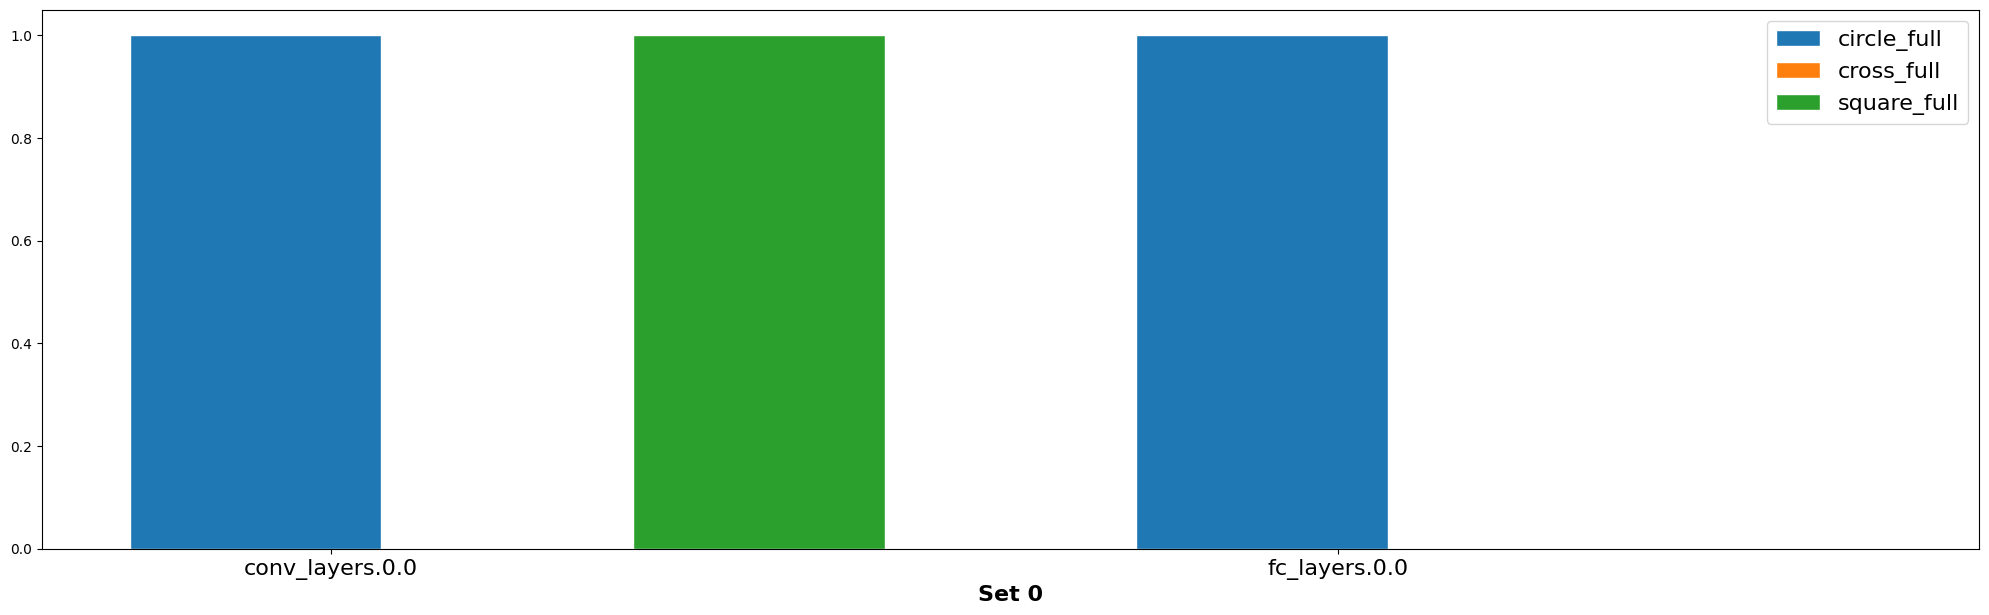

In [38]:
plot_tcav_scores(cross_concept_set, multi_fig_ncirc_results)

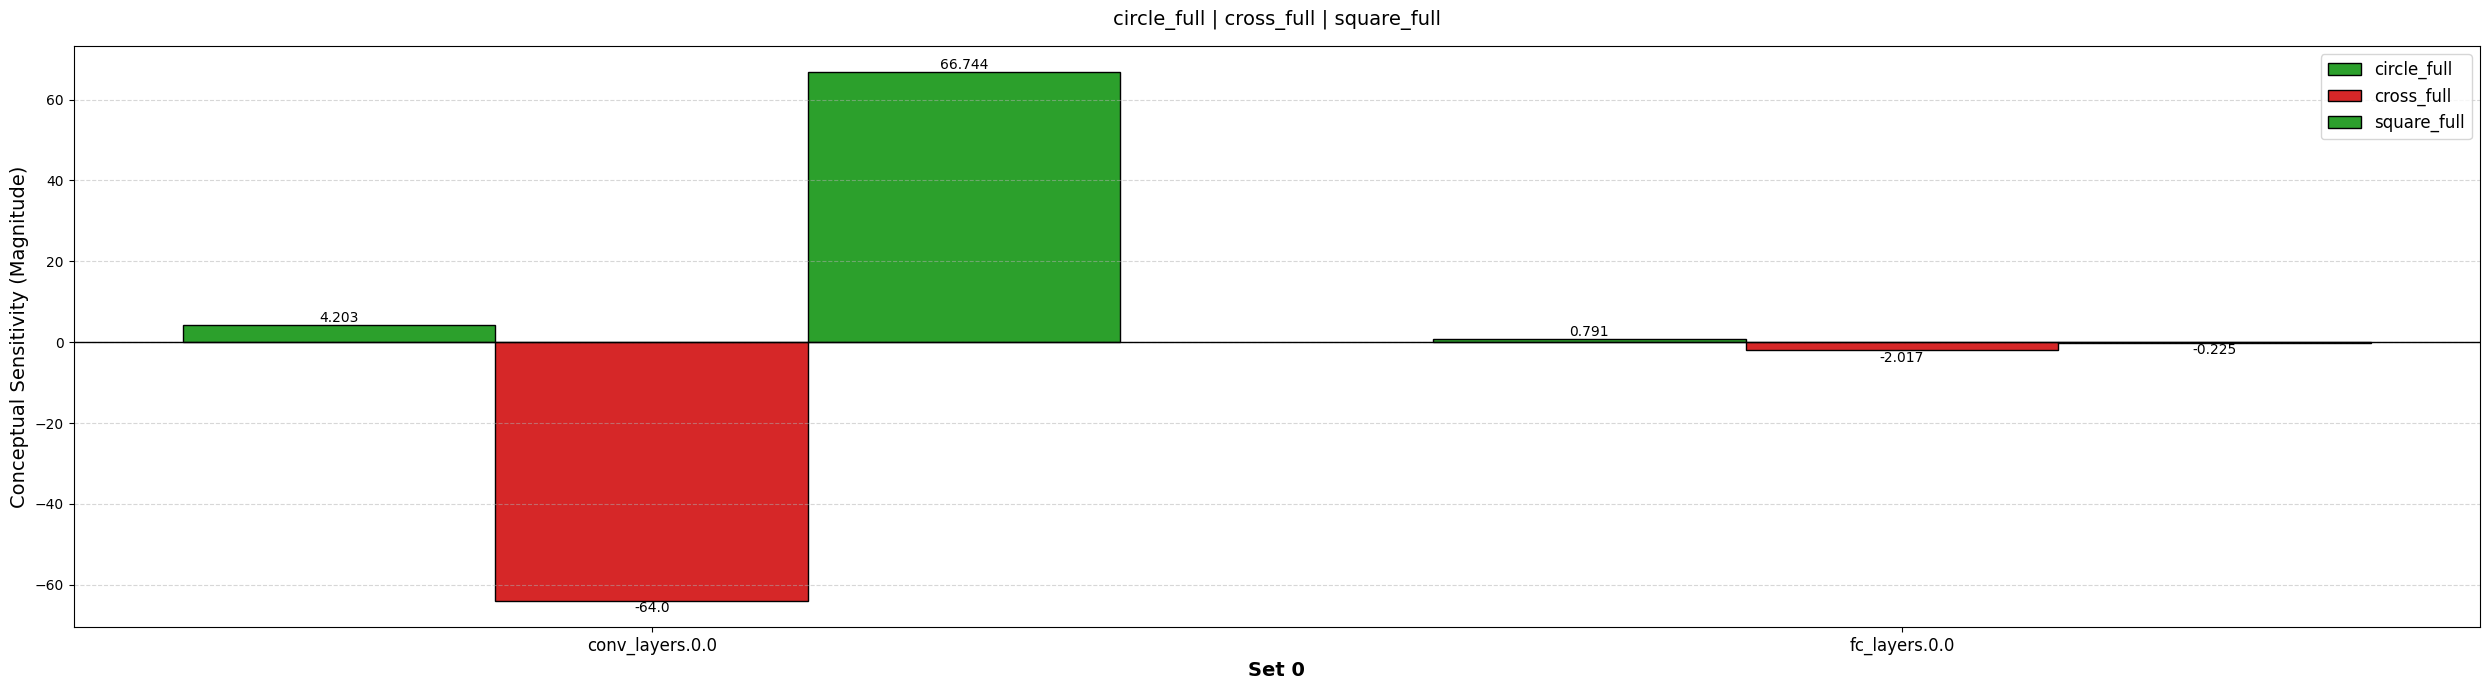

In [39]:
plot_conceptual_sensitivity(cross_concept_set, multi_fig_ncirc_results, LAYERS)

## Another image

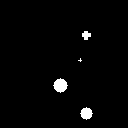

In [41]:
circle_test = Image.open("data/aixi_shape/val/00553.png").convert("L")
circle_test

In [42]:
x_multi_cr_cir = transform(Image.open("data/aixi_shape/val/00553.png").convert("RGB")).unsqueeze(0).to(DEVICE)
x_multi_cr_cir.shape

torch.Size([1, 3, 128, 128])

In [43]:
model(x_multi_cr_cir)

tensor([[52.0924]], grad_fn=<AddmmBackward0>)

In [44]:
mytcav = TCAV(model=model,
              layers=LAYERS,
              layer_attr_method = LayerIntegratedGradients(
                model, None, multiply_by_inputs=False))
multi_cr_cir_results = mytcav.interpret(inputs=x_multi_cr_cir,
                                        experimental_sets=cross_concept_set,
                                        target=0,
                                        n_steps=5,
                                       )
multi_fig_ncirc_results

/opt/miniconda3/lib/python3.12/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


defaultdict(<function captum.concept._core.tcav.TCAV.interpret.<locals>.<lambda>()>,
            {'0-1-2': defaultdict(None,
                         {'conv_layers.0.0': {'sign_count': tensor([1., 0., 1.]),
                           'magnitude': tensor([  4.2028, -64.0003,  66.7445])},
                          'fc_layers.0.0': {'sign_count': tensor([1., 0., 0.]),
                           'magnitude': tensor([ 0.7907, -2.0167, -0.2252])}})})

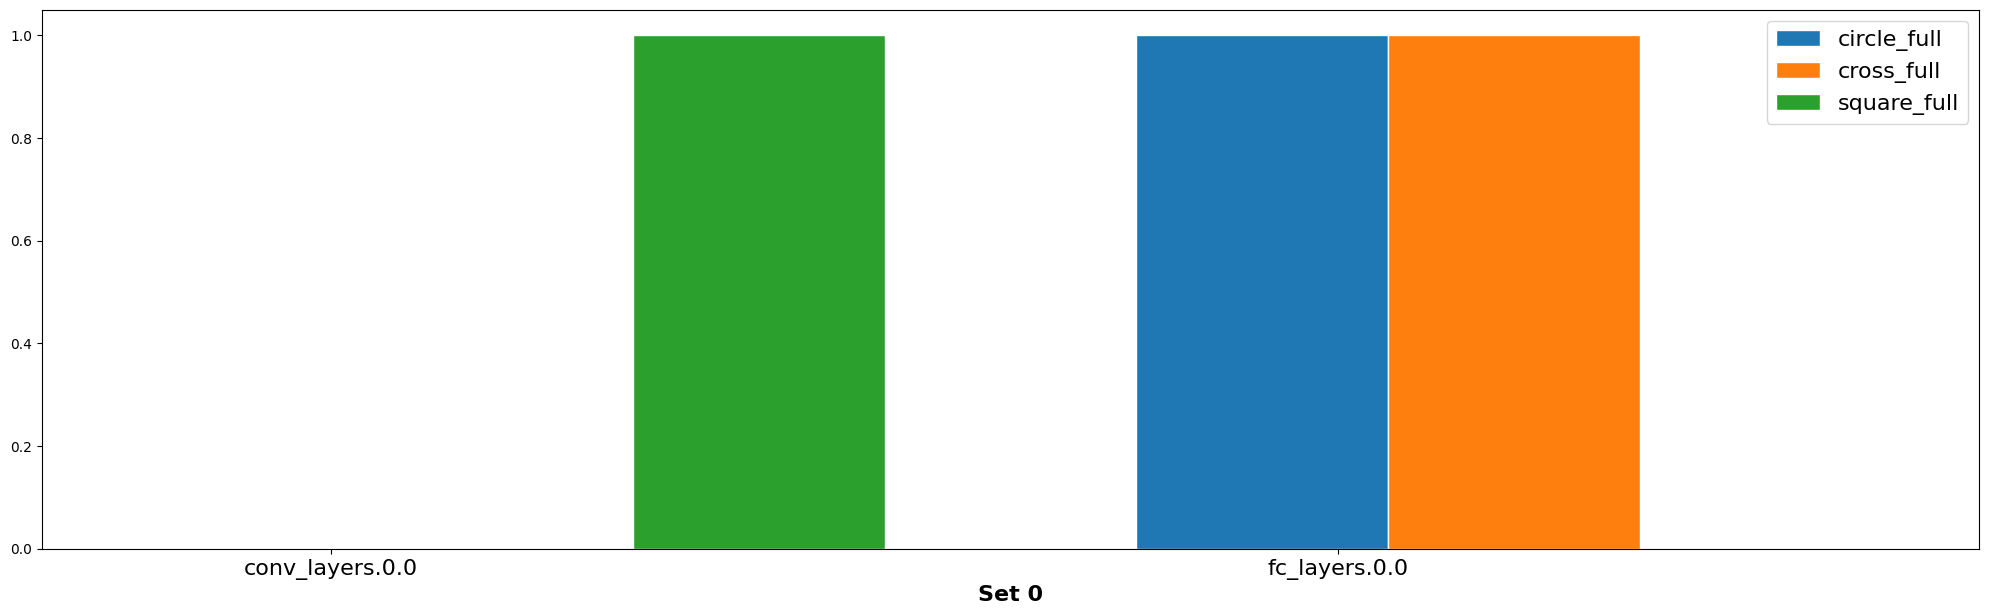

In [45]:
plot_tcav_scores(cross_concept_set, multi_cr_cir_results)

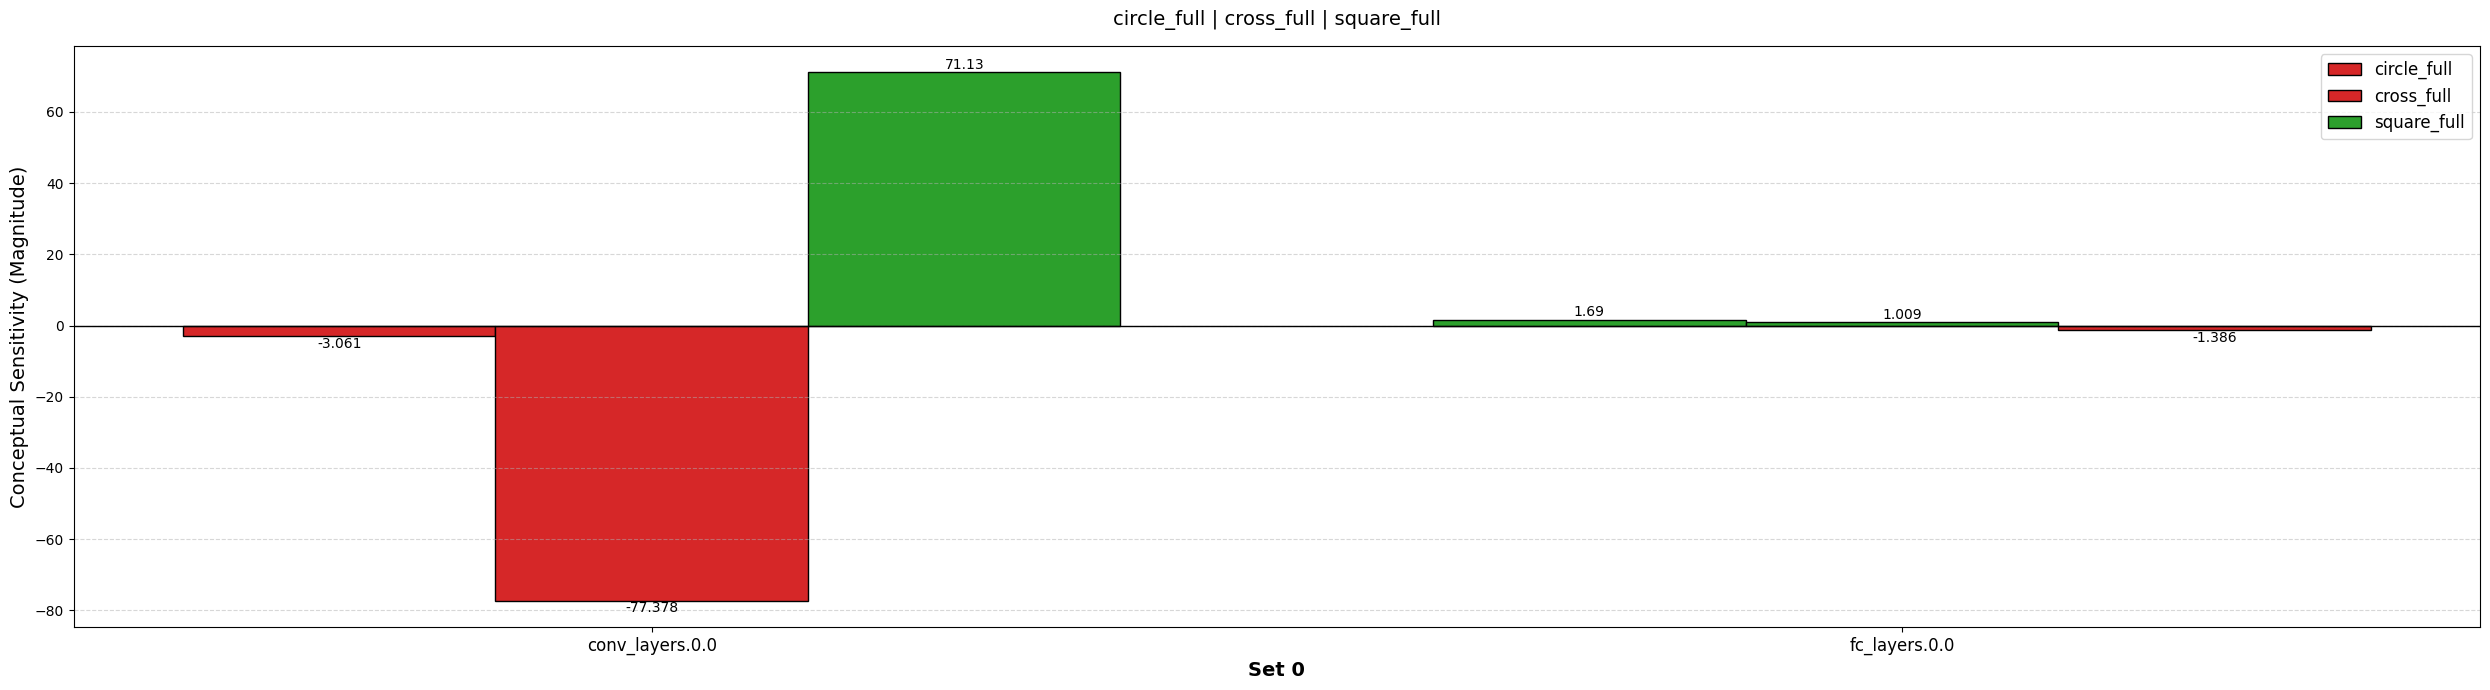

In [46]:
plot_conceptual_sensitivity(cross_concept_set, multi_cr_cir_results, LAYERS)

# Quick test of correlation of squares and circle


=== Basic Counts ===
has_circle    34834
has_square    34691
has_cross     34571
dtype: int64

=== Conditional Probability P(square | circle) ===
has_square         0         1
has_circle                    
0           0.334557  0.665443
1           0.332032  0.667968

=== Chi-square test ===
chi2=0.3188, p-value=0.572321, dof=1
Expected counts:
 [[ 5713.96719231 11452.03280769]
 [11595.03280769 23238.96719231]]

=== Correlation Matrix ===
            has_circle  has_square  has_cross
has_circle    1.000000    0.002519  -0.006981
has_square    0.002519    1.000000  -0.001600
has_cross    -0.006981   -0.001600   1.000000


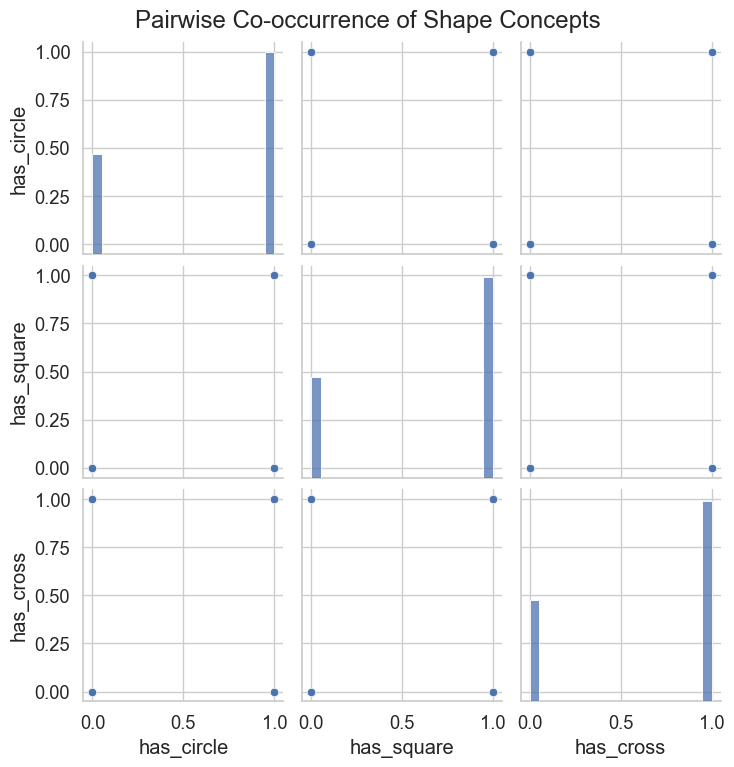

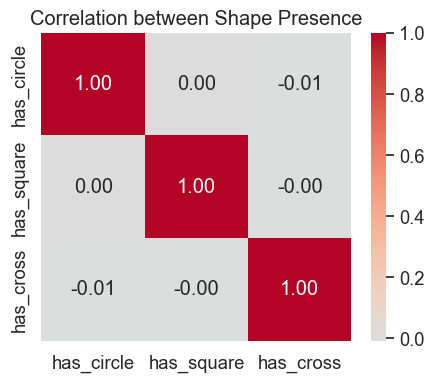

/var/folders/4p/rs128k3j0_l38wrfg8z1qwj00000gn/T/ipykernel_19122/80373055.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=proportions, x="has_circle", y="has_square", palette="viridis")


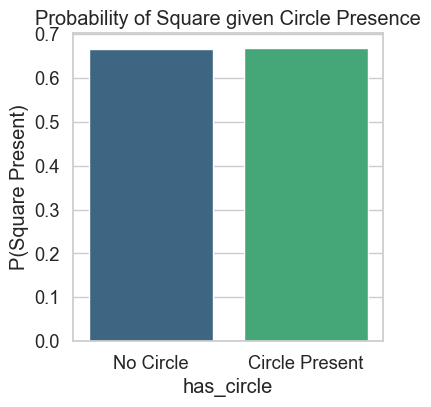

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load CSVs
train_df = pd.read_csv("data/dades_train.csv", sep=";")
val_df = pd.read_csv("data/dades.csv", sep=";")

# Rename first column (if unnamed)
first_col = train_df.columns[0]
train_df = train_df.rename(columns={first_col: "id"})
val_df = val_df.rename(columns={first_col: "id"})

# Ensure numeric types
for df in [train_df, val_df]:
    df[["id", "c", "s", "cr"]] = df[["id", "c", "s", "cr"]].apply(pd.to_numeric)

# Combine both datasets for full analysis
df = pd.concat([train_df.assign(split="train"), val_df.assign(split="val")], ignore_index=True)

# Binary indicators
df["has_circle"] = (df["c"] > 0).astype(int)
df["has_square"] = (df["s"] > 0).astype(int)
df["has_cross"] = (df["cr"] > 0).astype(int)

print("\n=== Basic Counts ===")
print(df[["has_circle", "has_square", "has_cross"]].sum())

# ---- 1️⃣ Cross-tabulation ----
ct = pd.crosstab(df["has_circle"], df["has_square"], normalize="index")
print("\n=== Conditional Probability P(square | circle) ===")
print(ct)

# ---- 2️⃣ Chi-square test for association ----
contingency = pd.crosstab(df["has_circle"], df["has_square"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print("\n=== Chi-square test ===")
print(f"chi2={chi2:.4f}, p-value={p:.6f}, dof={dof}")
print("Expected counts:\n", expected)

# ---- 3️⃣ Correlation between shapes ----
corr = df[["has_circle", "has_square", "has_cross"]].corr()
print("\n=== Correlation Matrix ===")
print(corr)

# ---- 4️⃣ Visualization ----
sns.set(style="whitegrid", font_scale=1.2)

# Pairplot to see co-occurrence
sns.pairplot(df[["has_circle", "has_square", "has_cross"]], diag_kind="hist")
plt.suptitle("Pairwise Co-occurrence of Shape Concepts", y=1.02)
plt.show()

# Heatmap of correlation
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation between Shape Presence")
plt.show()

# Barplot: proportion of squares in circle vs non-circle samples
proportions = df.groupby("has_circle")["has_square"].mean().reset_index()
plt.figure(figsize=(4, 4))
sns.barplot(data=proportions, x="has_circle", y="has_square", palette="viridis")
plt.xticks([0, 1], ["No Circle", "Circle Present"])
plt.ylabel("P(Square Present)")
plt.title("Probability of Square given Circle Presence")
plt.show()
